# FIFA World Cup 2026 Prediction Pipeline



## 1. Setup

In [1]:
# !pip install xgboost scikit-learn scipy pandas numpy matplotlib seaborn requests

import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
from io import StringIO
from datetime import datetime
from scipy.stats import poisson
from scipy.optimize import minimize
from sklearn.metrics import log_loss, accuracy_score
from sklearn.preprocessing import label_binarize
import xgboost as xgb

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "font.size": 11,
})
PALETTE = sns.color_palette("muted")

for d in ["data", "predictions"]:
    os.makedirs(d, exist_ok=True)

DATA_DIR  = "./data"
PRED_DATE = pd.Timestamp("2026-06-10")
HEADERS   = {"User-Agent": "Mozilla/5.0 (WC-predictor)"}

def log(msg):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}")

print("Environment ready.")


Environment ready.


## 2. Data Collection

### Dataset 1 — martj42/international_results
49,000+ international matches from 1872 to 2026. Used for Elo, form, and model training.

### Dataset 2 — jfjelstul/worldcup
Official FIFA World Cup database with historical groups, confederation info,
tournament standings, and the actual WC match records.

The 2026 fixture schedule comes from openfootball (same format, always current).

In [2]:
# Dataset 1: International results
log("Fetching international results ...")
url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
r = requests.get(url, headers=HEADERS, timeout=30)
r.raise_for_status()
results = pd.read_csv(StringIO(r.text), parse_dates=["date"])
results = results[["date","home_team","away_team","home_score","away_score","tournament","neutral"]]
results["result"] = results.apply(
    lambda row: "home_win" if row.home_score > row.away_score
           else ("away_win" if row.home_score < row.away_score else "draw"), axis=1)
results.to_csv(f"{DATA_DIR}/results.csv", index=False)

wc_results = results[results["tournament"].str.contains("FIFA World Cup", na=False)].copy()
wc_results.to_csv(f"{DATA_DIR}/wc_results.csv", index=False)

log(f"  Results: {len(results):,} matches ({results['date'].dt.year.min()}–{results['date'].dt.year.max()})")
log(f"  WC matches: {len(wc_results):,}")


[06:27:15] Fetching international results ...
[06:27:17]   Results: 49,368 matches (1872–2026)
[06:27:17]   WC matches: 9,807


In [3]:
# Dataset 2: jfjelstul worldcup database
BASE = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv"

log("Fetching jfjelstul worldcup database ...")

jf_matches = pd.read_csv(f"{BASE}/matches.csv", parse_dates=["match_date"])
jf_teams   = pd.read_csv(f"{BASE}/teams.csv")
jf_groups  = pd.read_csv(f"{BASE}/group_standings.csv")
jf_tourn   = pd.read_csv(f"{BASE}/tournament_standings.csv")

jf_matches.to_csv(f"{DATA_DIR}/jf_matches.csv", index=False)
jf_teams.to_csv(f"{DATA_DIR}/jf_teams.csv", index=False)
jf_groups.to_csv(f"{DATA_DIR}/jf_groups.csv", index=False)
jf_tourn.to_csv(f"{DATA_DIR}/jf_standings.csv", index=False)

log(f"  WC matches (all years): {len(jf_matches):,}")
log(f"  Teams with confederation: {len(jf_teams):,}")
log(f"  Group standings rows: {len(jf_groups):,}")
log(f"  Tournament standing rows: {len(jf_tourn):,}")


[06:27:17] Fetching jfjelstul worldcup database ...
[06:27:18]   WC matches (all years): 1,248
[06:27:18]   Teams with confederation: 88
[06:27:18]   Group standings rows: 626
[06:27:18]   Tournament standing rows: 120


In [4]:
# 2026 fixture schedule from openfootball
log("Fetching WC 2026 fixture schedule ...")
url = "https://raw.githubusercontent.com/openfootball/worldcup.json/master/2026/worldcup.json"
r = requests.get(url, headers=HEADERS, timeout=15)
r.raise_for_status()
raw = r.json()

fixture_rows = []
for m in raw.get("matches", []):
    fixture_rows.append({
        "round":   m.get("round", ""),
        "date":    m.get("date", ""),
        "team1":   m.get("team1", ""),
        "team2":   m.get("team2", ""),
        "group":   m.get("group", ""),
        "ground":  m.get("ground", ""),
        "score1":  m.get("score", {}).get("ft", [None, None])[0] if "score" in m else None,
        "score2":  m.get("score", {}).get("ft", [None, None])[1] if "score" in m else None,
    })

fixtures = pd.DataFrame(fixture_rows)
fixtures.to_csv(f"{DATA_DIR}/wc2026_fixtures.csv", index=False)

# Extract groups from fixtures
group_fix = fixtures[fixtures["group"].notna() & (fixtures["group"] != "")]
is_placeholder = lambda s: pd.isna(s) or str(s).startswith(("W","L","1","2","3"))
group_fix = group_fix[~group_fix["team1"].apply(is_placeholder) & ~group_fix["team2"].apply(is_placeholder)]

GROUPS_2026 = {}
for _, row in group_fix.iterrows():
    g = row["group"].replace("Group ", "").strip()
    GROUPS_2026.setdefault(g, set()).update([row["team1"], row["team2"]])
GROUPS_2026 = {k: sorted(v) for k, v in sorted(GROUPS_2026.items())}

log(f"  Fixtures: {len(fixtures)} total, {len(group_fix)} group stage")
log(f"  Groups found: {len(GROUPS_2026)} with {sum(len(v) for v in GROUPS_2026.values())} teams")
print()
for g, teams in GROUPS_2026.items():
    print(f"  Group {g}: {', '.join(teams)}")


[06:27:18] Fetching WC 2026 fixture schedule ...
[06:27:18]   Fixtures: 104 total, 72 group stage
[06:27:18]   Groups found: 12 with 48 teams

  Group A: Czech Republic, Mexico, South Africa, South Korea
  Group B: Bosnia & Herzegovina, Canada, Qatar, Switzerland
  Group C: Brazil, Haiti, Morocco, Scotland
  Group D: Australia, Paraguay, Turkey, USA
  Group E: Curaçao, Ecuador, Germany, Ivory Coast
  Group F: Japan, Netherlands, Sweden, Tunisia
  Group G: Belgium, Egypt, Iran, New Zealand
  Group H: Cape Verde, Saudi Arabia, Spain, Uruguay
  Group I: France, Iraq, Norway, Senegal
  Group J: Algeria, Argentina, Austria, Jordan
  Group K: Colombia, DR Congo, Portugal, Uzbekistan
  Group L: Croatia, England, Ghana, Panama


In [5]:
# Build team metadata from jfjelstul datasets (no hardcoding)
# Confederation from jf_teams, WC appearances and best result from jf_tourn

# Name map: jfjelstul uses current names, align with martj42 names where they differ
NAME_MAP = {
    "United States": "United States",
    "Türkiye": "Turkey",
    "IR Iran": "Iran",
    "Bosnia and Herzegovina": "Bosnia-Herzegovina",
    "DR Congo": "Congo DR",
    "Republic of Korea": "South Korea",
}

def fix_name(name):
    return NAME_MAP.get(name, name)

# Confederation lookup
conf_lookup = dict(zip(jf_teams["team_name"].apply(fix_name),
                       jf_teams["confederation_code"]))

# WC appearances and best finish per team from tournament standings
jf_tourn["team_norm"] = jf_tourn["team_name"].apply(fix_name)
wc_hist = (jf_tourn.groupby("team_norm")
           .agg(wc_apps=("tournament_id","count"),
                best_pos=("position","min"))
           .reset_index())

# Encode best position as round (1=Winner, 2=Runner-up, 3-4=SF, 5-8=QF, 9-16=R16, 17+=Group)
def pos_to_enc(pos):
    if pos == 1:   return 6  # Winner
    if pos == 2:   return 5  # Runner-up
    if pos <= 4:   return 4  # Semi-final
    if pos <= 8:   return 3  # Quarter-final
    if pos <= 16:  return 2  # Round of 16
    return 1                  # Group stage

wc_hist["best_enc"] = wc_hist["best_pos"].apply(pos_to_enc)
wc_hist_map = dict(zip(wc_hist["team_norm"],
                       wc_hist[["wc_apps","best_enc"]].to_dict("records")))

# Host teams for 2026
HOSTS_2026 = {"United States", "Mexico", "Canada"}

# Assemble team_meta for all 2026 qualified teams
all_2026_teams = sorted({t for tl in GROUPS_2026.values() for t in tl})
team_meta = {}
for team in all_2026_teams:
    hist = wc_hist_map.get(team, {"wc_apps": 0, "best_enc": 0})
    team_meta[team] = {
        "conf":    conf_lookup.get(team, "UNK"),
        "host":    team in HOSTS_2026,
        "wc_apps": hist["wc_apps"],
        "best_enc":hist["best_enc"],
    }

print(f"Team metadata built for {len(team_meta)} teams")
df_meta = pd.DataFrame([{"team":t,**v} for t,v in team_meta.items()]).sort_values("wc_apps",ascending=False)
print(df_meta.head(10).to_string(index=False))


Team metadata built for 48 teams
       team     conf  host  wc_apps  best_enc
     Brazil CONMEBOL False       13         6
    Germany     UEFA False       10         6
     France     UEFA False        8         6
     Sweden     UEFA False        8         5
Netherlands     UEFA False        6         5
  Argentina CONMEBOL False        6         6
    England     UEFA False        5         6
    Uruguay CONMEBOL False        5         6
     Norway     UEFA False        4         6
    Croatia     UEFA False        3         5


In [6]:
# Compute Elo ratings from full match history
log("Computing Elo ratings ...")

def calculate_elo(df, k_base=32, initial=1500):
    ratings, game_count, records = {}, {}, []
    get_elo  = lambda t: ratings.get(t, initial)
    expected = lambda ra, rb: 1 / (1 + 10 ** ((rb - ra) / 400))

    def get_k(team):
        n = game_count.get(team, 0)
        if n < 10: return k_base * 1.5
        if n < 30: return k_base
        return k_base * 0.75

    for _, row in df.sort_values("date").iterrows():
        h, a = row["home_team"], row["away_team"]
        rh, ra = get_elo(h), get_elo(a)
        eh = expected(rh, ra)
        sh = 1.0 if row.home_score > row.away_score else (0.0 if row.home_score < row.away_score else 0.5)
        kh, ka = get_k(h), get_k(a)
        ratings[h] = rh + kh * (sh - eh)
        ratings[a] = ra + ka * ((1-sh) - (1-eh))
        game_count[h] = game_count.get(h, 0) + 1
        game_count[a] = game_count.get(a, 0) + 1
        records += [
            {"date": row["date"], "team": h, "elo": round(ratings[h], 2)},
            {"date": row["date"], "team": a, "elo": round(ratings[a], 2)},
        ]

    return pd.DataFrame(records)

elo_df = calculate_elo(results)
elo_df.to_csv(f"{DATA_DIR}/elo_ratings.csv", index=False)
log(f"  Elo computed: {len(elo_df):,} records, {elo_df['team'].nunique()} teams")

# Elo snapshot at prediction date
elo_snap = (elo_df[elo_df["date"] <= PRED_DATE]
            .sort_values("date")
            .groupby("team").last()
            .reset_index()[["team","elo"]])
elo_map = dict(zip(elo_snap["team"], elo_snap["elo"]))
print(f"Pre-tournament Elo snapshot: {len(elo_map)} teams")
print("Top 10:", sorted([(t,round(e)) for t,e in elo_map.items() if t in all_2026_teams], key=lambda x:-x[1])[:10])


[06:27:18] Computing Elo ratings ...
[06:27:30]   Elo computed: 98,736 records, 336 teams
Pre-tournament Elo snapshot: 336 teams
Top 10: [('Spain', 1993), ('Argentina', 1989), ('France', 1956), ('Brazil', 1902), ('Portugal', 1891), ('England', 1890), ('Germany', 1882), ('Netherlands', 1879), ('Colombia', 1877), ('Japan', 1857)]


## 3. Exploratory Data Analysis

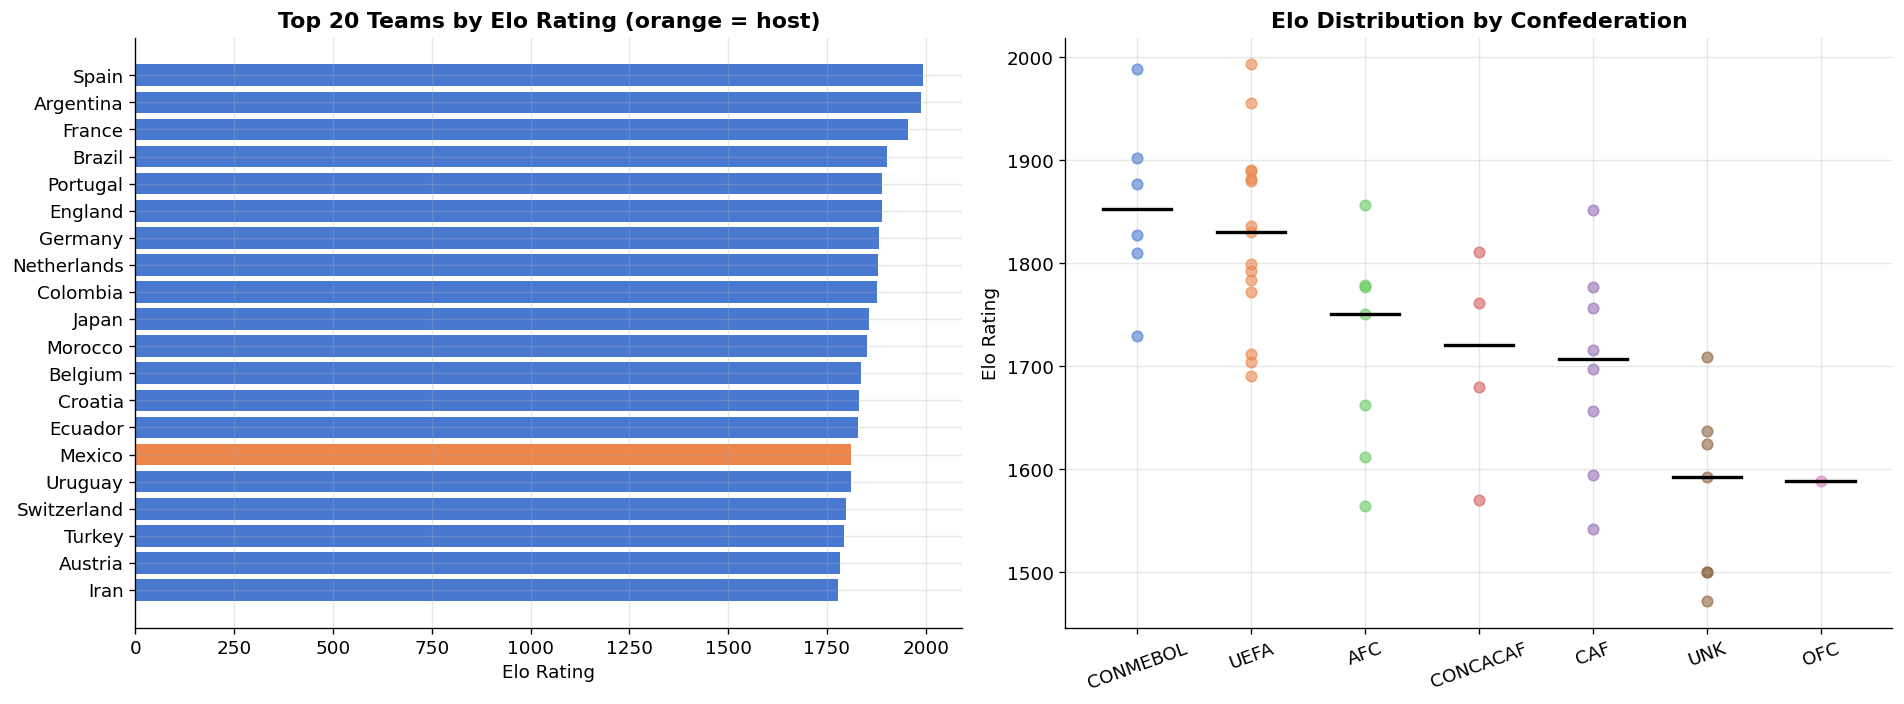

In [7]:
# EDA 1: Elo distribution for 2026 teams by confederation
df_elo_2026 = pd.DataFrame([
    {"team": t,
     "elo": elo_map.get(t, 1500),
     "confederation": team_meta[t]["conf"],
     "wc_apps": team_meta[t]["wc_apps"],
     "best_enc": team_meta[t]["best_enc"],
     "host": team_meta[t]["host"]}
    for t in all_2026_teams
]).sort_values("elo", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 Elo bar chart
top20 = df_elo_2026.head(20)
colors = [PALETTE[1] if h else PALETTE[0] for h in top20["host"]]
axes[0].barh(top20["team"][::-1], top20["elo"][::-1], color=colors[::-1])
axes[0].set_title("Top 20 Teams by Elo Rating (orange = host)", fontweight="bold")
axes[0].set_xlabel("Elo Rating")

# Elo by confederation (box)
conf_order = df_elo_2026.groupby("confederation")["elo"].median().sort_values(ascending=False).index
for i, conf in enumerate(conf_order):
    vals = df_elo_2026[df_elo_2026["confederation"]==conf]["elo"]
    axes[1].scatter([i]*len(vals), vals, alpha=0.6, s=40, color=PALETTE[i % len(PALETTE)])
    axes[1].plot([i-0.3, i+0.3], [vals.median(), vals.median()], "k-", linewidth=2)
axes[1].set_xticks(range(len(conf_order)))
axes[1].set_xticklabels(conf_order, rotation=20)
axes[1].set_title("Elo Distribution by Confederation", fontweight="bold")
axes[1].set_ylabel("Elo Rating")

plt.tight_layout()
plt.show()


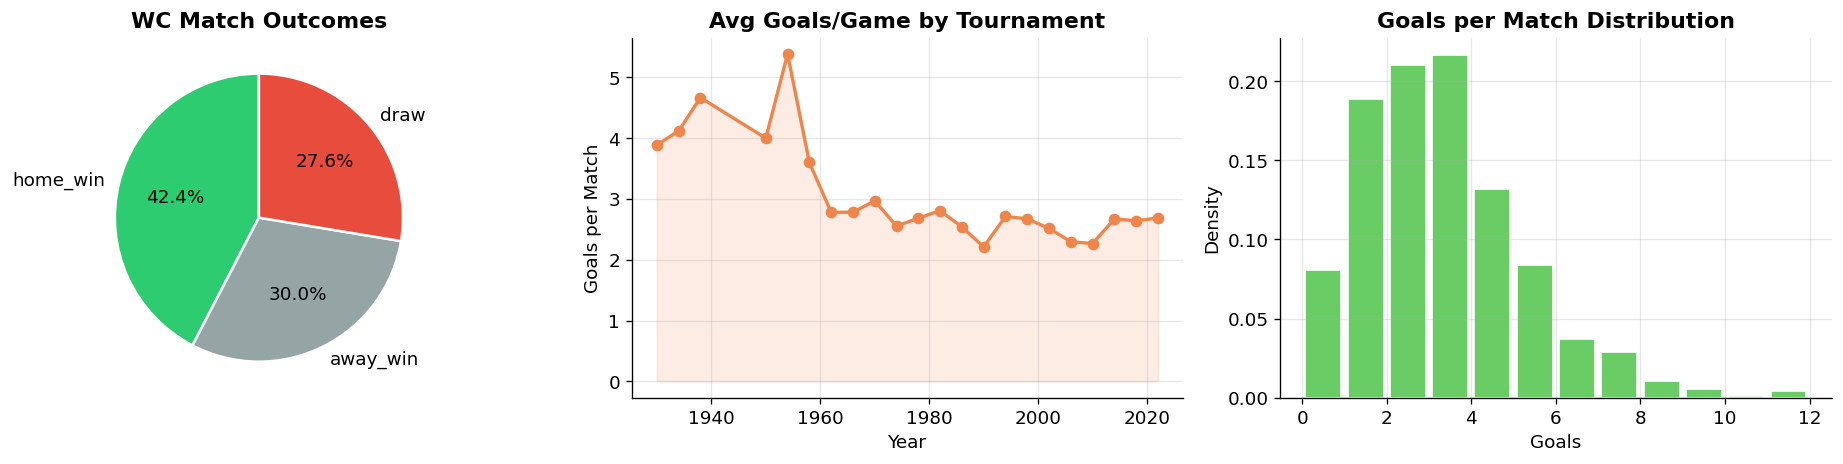

WC matches: 1,036  |  Avg goals: 2.82  |  Home win rate: 42.4%


In [8]:
# EDA 2: WC historical match outcomes and scoring trends
wc_off = wc_results[wc_results["tournament"]=="FIFA World Cup"].copy()
wc_off["total_goals"] = wc_off["home_score"] + wc_off["away_score"]
wc_off["year"] = wc_off["date"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Outcome distribution
oc = wc_off["result"].value_counts()
axes[0].pie(oc, labels=oc.index, autopct="%1.1f%%",
            colors=["#2ecc71","#95a5a6","#e74c3c"],
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("WC Match Outcomes", fontweight="bold")

# Goals per game trend
gpg = wc_off.groupby("year")["total_goals"].mean()
axes[1].plot(gpg.index, gpg.values, marker="o", color=PALETTE[1], linewidth=2)
axes[1].fill_between(gpg.index, gpg.values, alpha=0.15, color=PALETTE[1])
axes[1].set_title("Avg Goals/Game by Tournament", fontweight="bold")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Goals per Match")

# Goals per game histogram
axes[2].hist(wc_off["total_goals"], bins=range(0, 13),
             color=PALETTE[2], edgecolor="white", rwidth=0.85, density=True)
axes[2].set_title("Goals per Match Distribution", fontweight="bold")
axes[2].set_xlabel("Goals"); axes[2].set_ylabel("Density")

plt.tight_layout()
plt.show()
print(f"WC matches: {len(wc_off):,}  |  Avg goals: {wc_off['total_goals'].mean():.2f}  |  Home win rate: {(wc_off['result']=='home_win').mean():.1%}")


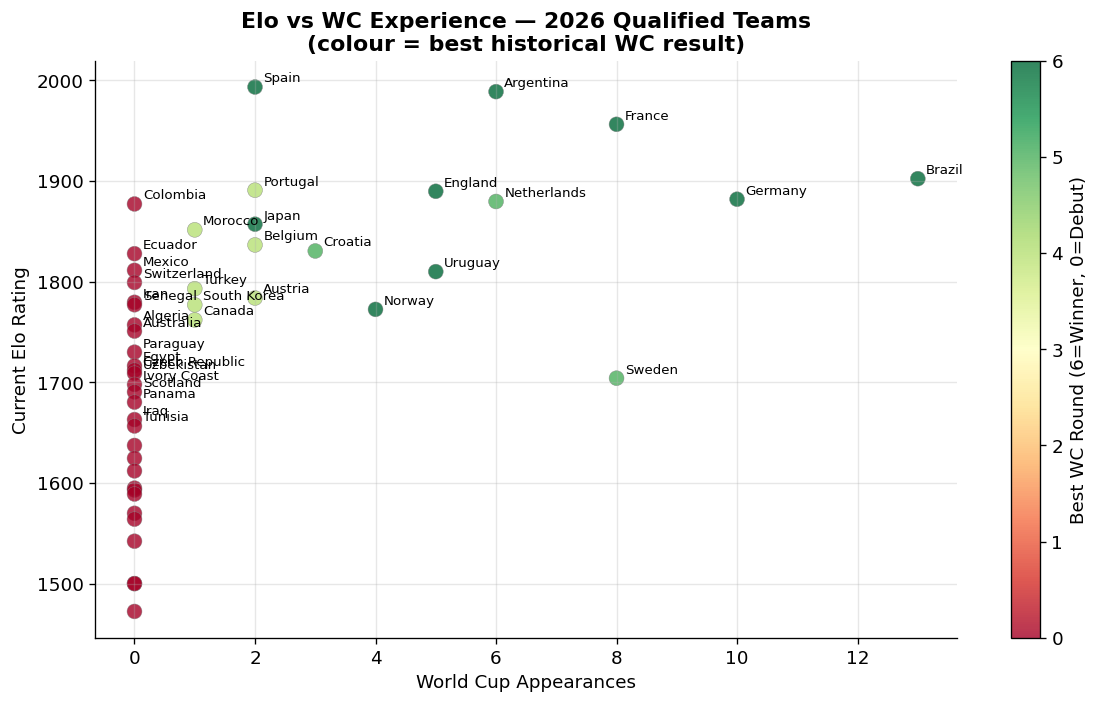

In [9]:
# EDA 3: WC appearances and Elo correlation (from jfjelstul data)
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_elo_2026["wc_apps"], df_elo_2026["elo"],
                c=df_elo_2026["best_enc"], cmap="RdYlGn",
                s=80, alpha=0.8, edgecolors="grey", linewidths=0.3)
plt.colorbar(sc, ax=ax, label="Best WC Round (6=Winner, 0=Debut)")

for _, row in df_elo_2026[df_elo_2026["elo"] > 1650].iterrows():
    ax.annotate(row["team"], (row["wc_apps"], row["elo"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

ax.set_xlabel("World Cup Appearances"); ax.set_ylabel("Current Elo Rating")
ax.set_title("Elo vs WC Experience — 2026 Qualified Teams\n(colour = best historical WC result)", fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Feature Engineering

18 features per match, built strictly from data available before the match date:

| Group | Features |
|-------|----------|
| Elo (4) | `elo_a`, `elo_b`, `elo_diff`, `elo_avg` |
| Form differentials (6) | win rate, GD, pts/game, clean sheet rate, avg GF, avg GA — A minus B |
| Context (8) | WC appearances, best round, host flag, H2H win rate — A vs B |

In [10]:
# Elo lookup (time-aware, no future leakage)
def build_elo_lookup(elo_df):
    lookup = {}
    for team, grp in elo_df.groupby("team"):
        gs = grp.sort_values("date")
        lookup[team] = (
            gs["date"].values.astype("datetime64[ns]"),
            gs["elo"].values.astype(float),
        )
    return lookup

def get_elo_before(lookup, team, before_date, default=1500.0):
    if team not in lookup:
        return default
    dates, elos = lookup[team]
    before_date = np.datetime64(before_date, "ns")
    idx = np.searchsorted(dates, before_date, side="left")
    return default if idx == 0 else float(elos[idx - 1])

elo_lookup = build_elo_lookup(elo_df)
print(f"Elo lookup: {len(elo_lookup)} teams")


Elo lookup: 336 teams


In [11]:
# Form features (last N games before match date)
FORM_PRIOR = {"win_rate":0.34,"avg_gf":1.4,"avg_ga":1.4,"gd":0.0,"pts_pg":1.27,"cs_rate":0.25}

def get_form(res, team, before_date, n=10):
    mask = (((res["home_team"]==team)|(res["away_team"]==team)) & (res["date"] < before_date))
    df = res[mask].sort_values("date").tail(n)
    if len(df) == 0:
        return dict(FORM_PRIOR)
    wins=draws=cs=0; gf_list=[]; ga_list=[]
    for _, row in df.iterrows():
        is_home = row["home_team"] == team
        gf = row["home_score"] if is_home else row["away_score"]
        ga = row["away_score"] if is_home else row["home_score"]
        if pd.isna(gf) or pd.isna(ga): continue
        gf_list.append(gf); ga_list.append(ga)
        if gf > ga: wins += 1
        elif gf == ga: draws += 1
        if ga == 0: cs += 1
    n_played = len(gf_list) or 1
    wgf = float(np.mean(gf_list)) if gf_list else FORM_PRIOR["avg_gf"]
    wga = float(np.mean(ga_list)) if ga_list else FORM_PRIOR["avg_ga"]
    return {
        "win_rate": round(wins/n_played, 4),
        "avg_gf":   round(wgf, 4),
        "avg_ga":   round(wga, 4),
        "gd":       round(wgf - wga, 4),
        "pts_pg":   round((3*wins + draws)/n_played, 4),
        "cs_rate":  round(cs/n_played, 4),
    }

# H2H win rate for team_a against team_b (last n meetings)
def get_h2h(res, ta, tb, before_date, n=8):
    mask = ((((res["home_team"]==ta)&(res["away_team"]==tb))|
              ((res["home_team"]==tb)&(res["away_team"]==ta)))
            & (res["date"] < before_date))
    df = res[mask].sort_values("date").tail(n)
    if len(df) == 0: return 0.5  # no history → neutral prior
    a_wins = total = 0
    for _, row in df.iterrows():
        gf = row["home_score"] if row["home_team"]==ta else row["away_score"]
        ga = row["away_score"] if row["home_team"]==ta else row["home_score"]
        if pd.isna(gf) or pd.isna(ga): continue
        total += 1
        if gf > ga: a_wins += 1
    return round(a_wins/total, 4) if total else 0.5

print("Feature functions ready.")


Feature functions ready.


In [12]:
# Master feature builder
FEATURE_COLS = [
    "neutral",
    "elo_a","elo_b","elo_diff","elo_avg",
    "form_win_rate_diff","form_gd_diff","form_pts_pg_diff",
    "form_cs_rate_diff","form_avg_gf_diff","form_avg_ga_diff",
    "h2h_a_win_rate",
    "a_wc_apps","b_wc_apps","wc_apps_diff",
    "a_best_enc","b_best_enc","best_enc_diff",
    "a_is_host","b_is_host",
]

def build_features(ta, tb, match_date, neutral, res, elo_lkp, meta):
    ea = get_elo_before(elo_lkp, ta, match_date)
    eb = get_elo_before(elo_lkp, tb, match_date)
    fa = get_form(res, ta, match_date)
    fb = get_form(res, tb, match_date)
    h2h = get_h2h(res, ta, tb, match_date)
    ma = meta.get(ta, {"wc_apps":0,"best_enc":0,"host":False})
    mb = meta.get(tb, {"wc_apps":0,"best_enc":0,"host":False})
    return {
        "neutral": int(neutral),
        "elo_a":  round(ea, 2), "elo_b":  round(eb, 2),
        "elo_diff": round(ea-eb, 2), "elo_avg": round((ea+eb)/2, 2),
        "form_win_rate_diff": round(fa["win_rate"] - fb["win_rate"], 4),
        "form_gd_diff":       round(fa["gd"]       - fb["gd"],       4),
        "form_pts_pg_diff":   round(fa["pts_pg"]   - fb["pts_pg"],   4),
        "form_cs_rate_diff":  round(fa["cs_rate"]  - fb["cs_rate"],  4),
        "form_avg_gf_diff":   round(fa["avg_gf"]   - fb["avg_gf"],   4),
        "form_avg_ga_diff":   round(fa["avg_ga"]   - fb["avg_ga"],   4),
        "h2h_a_win_rate":     h2h,
        "a_wc_apps":    ma["wc_apps"],  "b_wc_apps":    mb["wc_apps"],
        "wc_apps_diff": ma["wc_apps"] - mb["wc_apps"],
        "a_best_enc":   ma["best_enc"], "b_best_enc":   mb["best_enc"],
        "best_enc_diff":ma["best_enc"] - mb["best_enc"],
        "a_is_host": int(ma.get("host", False)),
        "b_is_host": int(mb.get("host", False)),
    }

print(f"Features per match: {len(FEATURE_COLS)}")


Features per match: 20


In [13]:
# Build training dataset from competitive matches 1990+
print("Building training dataset ...")

TOURNAMENT_WEIGHT = {
    "FIFA World Cup": 3.0, "UEFA Euro": 2.0, "Copa America": 2.0,
    "AFC Asian Cup": 1.8, "Africa Cup of Nations": 1.8,
    "FIFA World Cup qualification": 1.5,
}

def get_weight(t):
    for k, w in TOURNAMENT_WEIGHT.items():
        if k.lower() in str(t).lower(): return w
    return 1.0

def is_competitive(t):
    t = str(t).lower()
    return "friendly" not in t and any(k in t for k in [
        "world cup","euro","copa america","africa cup","asian cup",
        "gold cup","nations","championship","qualifier"])

train_pool = results[
    (results["date"] >= "1990-01-01") &
    results["tournament"].apply(is_competitive)
].dropna(subset=["home_score","away_score"]).copy()

print(f"Pool: {len(train_pool):,} matches from {train_pool['tournament'].nunique()} competitions")

rows = []
for _, match in train_pool.iterrows():
    try:
        feats = build_features(
            match["home_team"], match["away_team"],
            match["date"], bool(match.get("neutral", True)),
            results, elo_lookup, team_meta)
    except Exception:
        continue
    hs, ag = match["home_score"], match["away_score"]
    feats.update({
        "home_goals": int(hs), "away_goals": int(ag),
        "outcome":    2 if hs>ag else (1 if hs==ag else 0),
        "weight":     get_weight(match["tournament"]),
        "home_team":  match["home_team"],
        "away_team":  match["away_team"],
        "date":       match["date"],
    })
    rows.append(feats)

df_train = pd.DataFrame(rows)
df_train.to_csv(f"{DATA_DIR}/features_train.csv", index=False)
print(f"Training set: {df_train.shape[0]:,} rows x {df_train.shape[1]} cols")
print(f"Outcome split: {df_train['outcome'].value_counts().sort_index().to_dict()} (0=B wins, 1=draw, 2=A wins)")


Building training dataset ...
Pool: 16,003 matches from 36 competitions
Training set: 16,003 rows x 27 cols
Outcome split: {0: 4669, 1: 3436, 2: 7898} (0=B wins, 1=draw, 2=A wins)


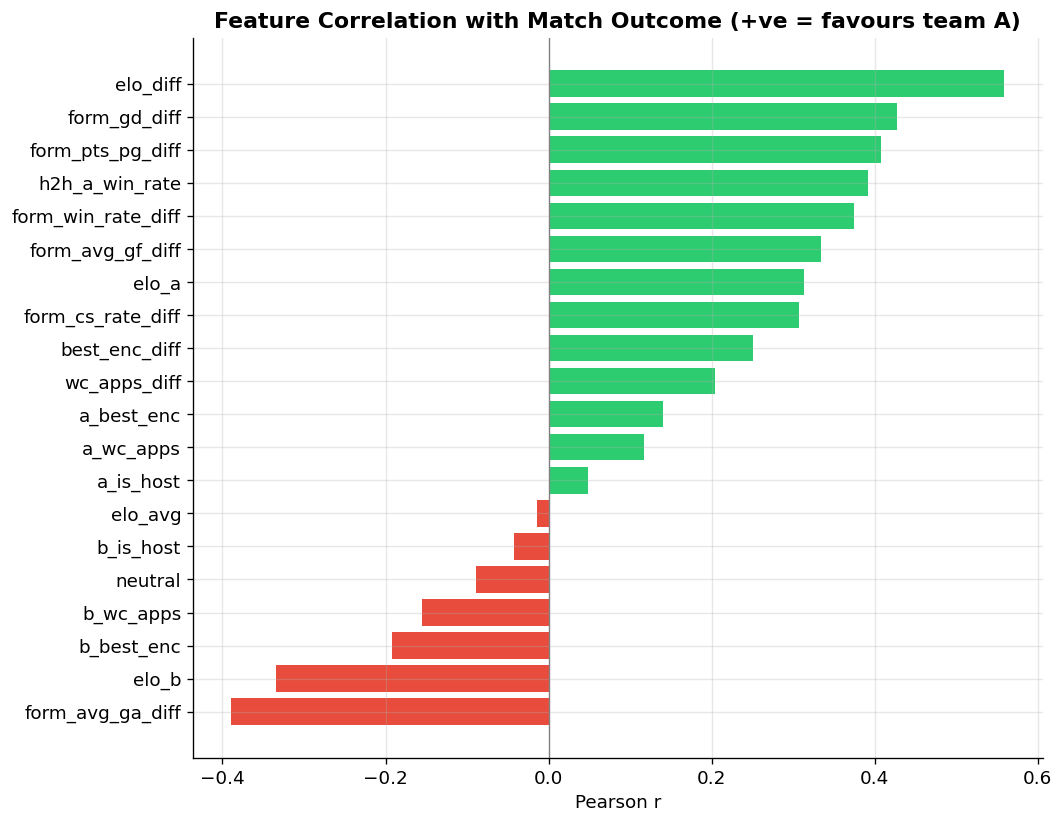

In [14]:
# Feature correlations
corr = df_train[FEATURE_COLS + ["outcome"]].corr()["outcome"].drop("outcome").sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(corr.index, corr.values,
        color=["#e74c3c" if v < 0 else "#2ecc71" for v in corr])
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Feature Correlation with Match Outcome (+ve = favours team A)", fontweight="bold")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()


## 5. Model Training

- **XGBoost** — gradient-boosted trees on the 20 features
- **Double Poisson (Dixon-Coles)** — fits per-team attack/defence parameters from goal data
- **Ensemble** — 60% XGBoost + 40% Poisson, validated by walk-forward CV

In [15]:
# Model definitions
XGB_PARAMS = {
    "objective":"multi:softprob","num_class":3,
    "n_estimators":400,"max_depth":4,"learning_rate":0.05,
    "subsample":0.8,"colsample_bytree":0.8,
    "reg_alpha":0.5,"reg_lambda":1.5,"min_child_weight":3,
    "eval_metric":"mlogloss","random_state":42,"n_jobs":-1,
    "verbosity":0,"early_stopping_rounds":30,
}

def train_xgb(X_tr, y_tr, w_tr=None):
    from sklearn.model_selection import train_test_split
    m = xgb.XGBClassifier(**XGB_PARAMS)
    if len(X_tr) >= 20:
        sw = w_tr if w_tr is not None else np.ones(len(y_tr))
        X_t,X_v,y_t,y_v,wt,_ = train_test_split(
            X_tr,y_tr,sw,test_size=0.15,random_state=42,stratify=y_tr)
        m.fit(X_t,y_t,sample_weight=wt,eval_set=[(X_v,y_v)],verbose=False)
    else:
        params = {k:v for k,v in XGB_PARAMS.items() if k!="early_stopping_rounds"}
        m = xgb.XGBClassifier(**params)
        m.fit(X_tr,y_tr,sample_weight=w_tr,verbose=False)
    return m


class DoublePoisson:
    def __init__(self):
        self.attack = {}; self.defence = {}; self.home_adv = 0.0

    def fit(self, df):
        teams = sorted(set(df["home_team"].tolist() + df["away_team"].tolist()))
        n = len(teams); idx = {t:i for i,t in enumerate(teams)}
        ht = df["home_team"].map(idx).values
        at = df["away_team"].map(idx).values
        hg = df["home_goals"].values.astype(int)
        ag = df["away_goals"].values.astype(int)

        def nll(params):
            att=params[:n]; dfe=params[n:2*n]; ha=params[2*n]
            lh = np.exp(att[ht]-dfe[at]+ha).clip(1e-6)
            la = np.exp(att[at]-dfe[ht]).clip(1e-6)
            return -np.sum(poisson.logpmf(hg,lh) + poisson.logpmf(ag,la))

        x0 = np.zeros(2*n+1); x0[2*n] = 0.1
        opt = minimize(nll, x0, method="L-BFGS-B",
                       options={"maxiter":500,"ftol":1e-8}).x
        self.attack  = {t: opt[idx[t]]   for t in teams}
        self.defence = {t: opt[n+idx[t]] for t in teams}
        self.home_adv = float(opt[2*n])

    def predict_proba(self, ta, tb, neutral=True, max_goals=10):
        ha = 0.0 if neutral else self.home_adv
        la = max(np.exp(self.attack.get(ta,0) - self.defence.get(tb,0) + ha), 1e-6)
        lb = max(np.exp(self.attack.get(tb,0) - self.defence.get(ta,0)), 1e-6)
        pw = pd_ = pl = 0.0
        for ga in range(max_goals+1):
            for gb in range(max_goals+1):
                p = poisson.pmf(ga,la) * poisson.pmf(gb,lb)
                if   ga > gb: pw  += p
                elif ga == gb: pd_ += p
                else:          pl  += p
        arr = np.array([pl,pd_,pw]); arr /= arr.sum()
        return arr

    def predict_batch(self, df):
        ca = "team_a" if "team_a" in df.columns else "home_team"
        cb = "team_b" if "team_b" in df.columns else "away_team"
        return np.array([self.predict_proba(row[ca], row[cb])
                         for _, row in df.iterrows()])


def blend(xp, pp, w=0.6):
    b = np.clip(w*xp + (1-w)*pp, 1e-7, 1-1e-7)
    return b / b.sum(1, keepdims=True)

def eval_probs(y_true, y_prob, label=""):
    y_pred = np.argmax(y_prob, axis=1)
    y_bin  = label_binarize(y_true, classes=[0,1,2])
    m = {
        "log_loss": log_loss(y_true, y_prob),
        "brier":    float(np.mean(np.sum((y_prob - y_bin)**2, axis=1))),
        "accuracy": accuracy_score(y_true, y_pred),
    }
    if label:
        print(f"  {label:<25}  log-loss={m['log_loss']:.4f}  brier={m['brier']:.4f}  acc={m['accuracy']:.3f}")
    return m

print("Models defined.")


Models defined.


In [16]:
# Walk-forward cross-validation
df_cv_in = df_train.copy()
df_cv_in["year"] = pd.to_datetime(df_cv_in["date"]).dt.year
years = sorted(df_cv_in["year"].unique())
WC_YEARS = {1994,1998,2002,2006,2010,2014,2018,2022}

cv_rows = []
print("Walk-forward CV ...")
for i, test_year in enumerate(years[2:], start=2):
    df_tr = df_cv_in[df_cv_in["year"].isin(years[:i])]
    df_te = df_cv_in[df_cv_in["year"] == test_year]
    if len(df_te) == 0: continue

    X_tr = df_tr[FEATURE_COLS].values
    y_tr = df_tr["outcome"].values
    w_tr = df_tr["weight"].values
    X_te = df_te[FEATURE_COLS].values
    y_te = df_te["outcome"].values

    xgb_m = train_xgb(X_tr, y_tr, w_tr)
    xp_te = xgb_m.predict_proba(X_te)

    poi = DoublePoisson()
    poi.fit(df_tr[["home_team","away_team","home_goals","away_goals"]])
    pp_te = poi.predict_batch(df_te)

    ep_te = blend(xp_te, pp_te, w=0.6)
    mx = eval_probs(y_te, xp_te)
    mp = eval_probs(y_te, pp_te)
    me = eval_probs(y_te, ep_te)
    cv_rows.append({"year":test_year,"is_wc":int(test_year in WC_YEARS),
        "xgb_ll":mx["log_loss"],"poi_ll":mp["log_loss"],"ens_ll":me["log_loss"],
        "xgb_acc":mx["accuracy"],"poi_acc":mp["accuracy"],"ens_acc":me["accuracy"]})

df_cv = pd.DataFrame(cv_rows)
wc_cv = df_cv[df_cv["is_wc"]==1]
print("\nWC-fold summary (average across WC test years):")
for m in ["xgb","poi","ens"]:
    print(f"  {m.upper():<5}  log-loss={wc_cv[f'{m}_ll'].mean():.4f}  acc={wc_cv[f'{m}_acc'].mean():.3f}")


Walk-forward CV ...

WC-fold summary (average across WC test years):
  XGB    log-loss=0.9010  acc=0.591
  POI    log-loss=0.9562  acc=0.556
  ENS    log-loss=0.8913  acc=0.587


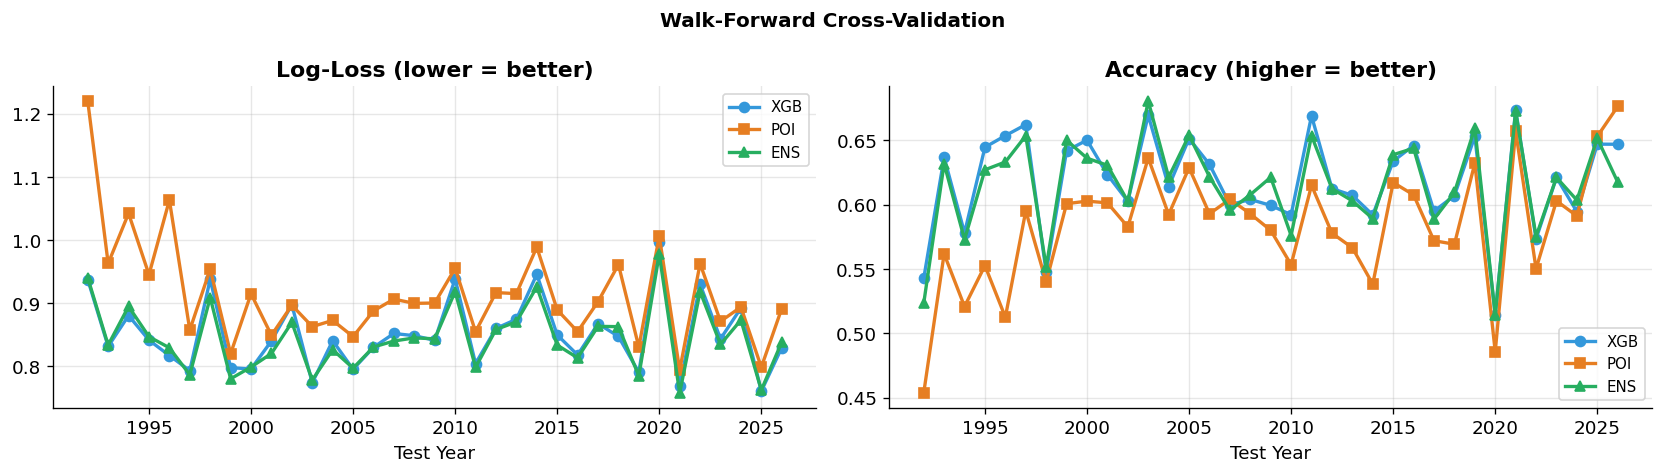

In [17]:
# CV plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col, title, better) in zip(axes, [
    ("ll","Log-Loss","lower"), ("acc","Accuracy","higher")]):
    for model, color, marker in [("xgb","#3498db","o"),("poi","#e67e22","s"),("ens","#27ae60","^")]:
        ax.plot(df_cv["year"], df_cv[f"{model}_{col}"], marker=marker,
                label=model.upper(), color=color, linewidth=2)
    ax.set_title(f"{title} ({better} = better)", fontweight="bold")
    ax.set_xlabel("Test Year"); ax.legend(fontsize=9)
plt.suptitle("Walk-Forward Cross-Validation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


Training final model on full dataset ...


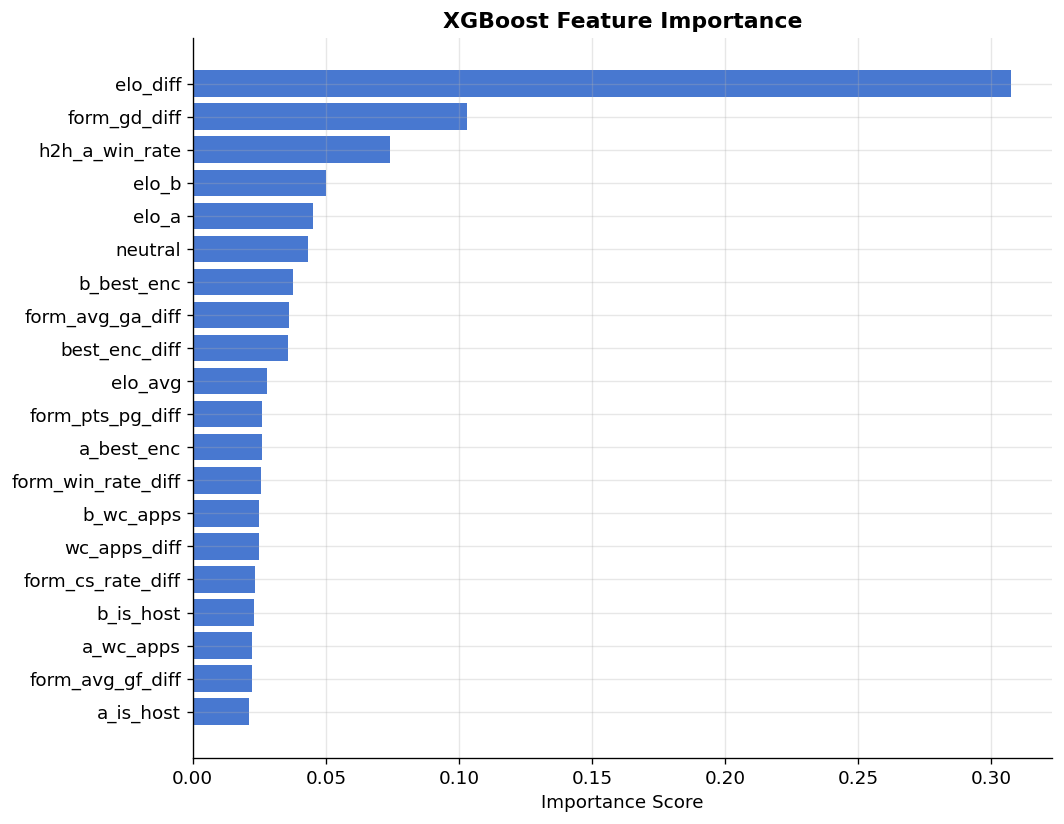


Top 10 features:
         feature  importance
        elo_diff    0.307619
    form_gd_diff    0.103139
  h2h_a_win_rate    0.074054
           elo_b    0.049894
           elo_a    0.045266
         neutral    0.043189
      b_best_enc    0.037620
form_avg_ga_diff    0.036289
   best_enc_diff    0.035637
         elo_avg    0.027831


In [18]:
# Train final model on all data
print("Training final model on full dataset ...")
X_all = df_train[FEATURE_COLS].values
y_all = df_train["outcome"].values
w_all = df_train["weight"].values

xgb_final = train_xgb(X_all, y_all, w_all)

poi_final = DoublePoisson()
poi_final.fit(df_train[["home_team","away_team","home_goals","away_goals"]])

def predict(X_new, df_new=None, w_xgb=0.6):
    xp = xgb_final.predict_proba(X_new)
    pp = poi_final.predict_batch(df_new) if df_new is not None else np.full_like(xp, 1/3)
    return blend(xp, pp, w_xgb), xp, pp

# Feature importance
fi = pd.DataFrame({"feature":FEATURE_COLS,"importance":xgb_final.feature_importances_})
fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=PALETTE[0])
ax.set_title("XGBoost Feature Importance", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(fi.head(10).to_string(index=False))


## 6. Group Stage Predictions

In [19]:
# Build prediction features for all 72 group fixtures
# Teams and groups come from the openfootball 2026 fixture data (no hardcoding)
rows_pred = []
for g, teams in GROUPS_2026.items():
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            ta, tb = teams[i], teams[j]
            feats = build_features(ta, tb, PRED_DATE, True, results, elo_lookup, team_meta)
            feats["team_a"] = ta; feats["team_b"] = tb; feats["group"] = f"Group {g}"
            rows_pred.append(feats)

df_pred = pd.DataFrame(rows_pred)
X_pred = df_pred[FEATURE_COLS].values
ep, xp, pp = predict(X_pred, df_pred)

pred_rows = []
for i, (_, row) in enumerate(df_pred.iterrows()):
    p_b, p_d, p_a = ep[i]
    pred_rows.append({
        "group":  row["group"],
        "team_a": row["team_a"],
        "team_b": row["team_b"],
        "p_a_win": round(float(p_a), 4),
        "p_draw":  round(float(p_d), 4),
        "p_b_win": round(float(p_b), 4),
        "favourite": row["team_a"] if p_a > p_b else (row["team_b"] if p_b > p_a else "Draw"),
    })

df_preds = pd.DataFrame(pred_rows)
df_preds.to_csv("./predictions/group_stage_probs.csv", index=False)
print(f"Saved {len(df_preds)} group stage predictions.")


Saved 72 group stage predictions.


In [20]:
# Print group tables
print("=" * 65)
print("  WC 2026 GROUP STAGE PREDICTIONS")
print("=" * 65)
for group in sorted(df_preds["group"].unique()):
    g = df_preds[df_preds["group"] == group]
    print(f"\n  {group}")
    print(f"  {'Team A':<22} {'Team B':<22} {'A Win':>7} {'Draw':>7} {'B Win':>7}")
    for _, row in g.iterrows():
        print(f"  {row['team_a']:<22} {row['team_b']:<22} "
              f"{row['p_a_win']:>7.1%} {row['p_draw']:>7.1%} {row['p_b_win']:>7.1%}")


  WC 2026 GROUP STAGE PREDICTIONS

  Group A
  Team A                 Team B                   A Win    Draw   B Win
  Czech Republic         Mexico                   16.9%   28.3%   54.8%
  Czech Republic         South Africa             48.3%   28.6%   23.1%
  Czech Republic         South Korea              25.3%   30.5%   44.2%
  Mexico                 South Africa             72.2%   18.3%    9.5%
  Mexico                 South Korea              46.7%   29.3%   24.0%
  South Africa           South Korea              18.0%   29.6%   52.4%

  Group B
  Team A                 Team B                   A Win    Draw   B Win
  Bosnia & Herzegovina   Canada                   10.0%   21.3%   68.7%
  Bosnia & Herzegovina   Qatar                    22.0%   24.7%   53.3%
  Bosnia & Herzegovina   Switzerland              11.8%   22.7%   65.5%
  Canada                 Qatar                    57.8%   26.8%   15.4%
  Canada                 Switzerland              38.6%   26.9%   34.5%
  Qatar 

## 7. Monte Carlo Simulation (10,000 runs)

In [21]:
# Match probability helpers
prob_lookup = {}
for _, row in df_preds.iterrows():
    a, b = row["team_a"], row["team_b"]
    arr  = np.array([row["p_b_win"], row["p_draw"], row["p_a_win"]], dtype=float)
    arr /= arr.sum()
    prob_lookup[(a, b)] = arr
    prob_lookup[(b, a)] = arr[::-1].copy()

def elo_probs(ea, eb):
    diff = ea - eb
    pnl  = 1 / (1 + 10 ** (-diff/400))
    drw  = 0.27 * np.exp(-((diff/400)**2)/0.5)
    pa   = np.clip(pnl - drw/2, 0.02, 0.96)
    pb   = np.clip(1-pnl - drw/2, 0.02, 0.96)
    pd_  = np.clip(drw, 0.02, 0.60)
    arr  = np.array([pb, pd_, pa]); return arr/arr.sum()

def get_probs(ta, tb, knockout=False):
    p = prob_lookup.get((ta, tb))
    if p is None:
        p = elo_probs(elo_map.get(ta,1500), elo_map.get(tb,1500))
    if knockout:
        pb, _, pa = p; tot = pb + pa
        p = np.array([pb/tot, 0.0, pa/tot])
    return p

def sim_match(ta, tb, knockout=False):
    p = np.clip(get_probs(ta, tb, knockout), 0, 1); p /= p.sum()
    out = np.random.choice([0, 1, 2], p=p)
    if knockout: return (ta, tb) if out==2 else (tb, ta)
    return (3, 0) if out==2 else ((1, 1) if out==1 else (0, 3))

print("Simulation helpers ready.")


Simulation helpers ready.


In [22]:
# Tournament simulator
# Groups come from GROUPS_2026 (fetched from openfootball)
# Bracket structure follows FIFA 2026: R32 → R16 → QF → SF → Final

THIRD_SLOTS = ["3ABCD","3EFGH","3IJKL","3ABEF","3CDIJ","3GHKL","3BCDE","3FGHI"]

R32_PAIRS = [
    ("1A","2B"),("1C","2D"),("1E","2F"),("1G","2H"),
    ("1I","2J"),("1K","2L"),("1B","2A"),("1D","2C"),
    ("1F","2E"),("1H","2G"),("1J","2I"),("1L","2K"),
    ("3ABCD","3EFGH"),("3IJKL","3ABEF"),("3CDIJ","3GHKL"),("3BCDE","3FGHI"),
]

STAGES = ["group","r32","r16","qf","sf","final","champion"]

def sim_group(teams):
    pts = {t:0 for t in teams}; gd = {t:0 for t in teams}
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            a, b = teams[i], teams[j]
            pa, pb = sim_match(a, b, knockout=False)
            pts[a]+=pa; pts[b]+=pb
            if   pa > pb: gd[a]+=1; gd[b]-=1
            elif pb > pa: gd[b]+=1; gd[a]-=1
    return sorted(teams, key=lambda t:(pts[t],gd[t],np.random.random()), reverse=True), pts, gd

def sim_tournament():
    all_teams = [t for tl in GROUPS_2026.values() for t in tl]
    stage = {t:"group" for t in all_teams}
    slot  = {}; thirds = []

    for g, teams in GROUPS_2026.items():
        standing, pts, gd = sim_group(teams)
        slot[f"1{g}"] = standing[0]; stage[standing[0]] = "r32"
        slot[f"2{g}"] = standing[1]; stage[standing[1]] = "r32"
        thirds.append({"team":standing[2],"pts":pts[standing[2]],"gd":gd[standing[2]]})

    best8 = (pd.DataFrame(thirds)
             .sort_values(["pts","gd"], ascending=False)
             .head(8)["team"].tolist())
    for i, team in enumerate(best8):
        slot[THIRD_SLOTS[i]] = team; stage[team] = "r32"

    winners = []
    for sa, sb in R32_PAIRS:
        ta = slot.get(sa); tb = slot.get(sb)
        if ta is None or tb is None: continue
        w, _ = sim_match(ta, tb, knockout=True)
        winners.append(w); stage[w] = "r16"

    for next_s in ["qf","sf","final","champion"]:
        nxt = []
        for i in range(0, len(winners)-1, 2):
            w, _ = sim_match(winners[i], winners[i+1], knockout=True)
            nxt.append(w); stage[w] = next_s
        winners = nxt
        if len(winners) == 1:
            stage[winners[0]] = "champion"; break

    return stage

print("Tournament simulator ready.")


Tournament simulator ready.


In [23]:
# Run 10,000 simulations
N_SIMS = 10_000
np.random.seed(42)
all_teams_flat = [t for tl in GROUPS_2026.values() for t in tl]
stage_counts = {t:{s:0 for s in STAGES} for t in all_teams_flat}

print(f"Running {N_SIMS:,} simulations ...")
for i in range(N_SIMS):
    if (i+1) % 2000 == 0: print(f"  {i+1:,}/{N_SIMS:,}")
    result = sim_tournament()
    for team, stage in result.items():
        idx = STAGES.index(stage)
        for s in STAGES[:idx+1]: stage_counts[team][s] += 1

print("Done.")


Running 10,000 simulations ...
  2,000/10,000
  4,000/10,000
  6,000/10,000
  8,000/10,000
  10,000/10,000
Done.


In [24]:
# Results table
team_group = {t:g for g,tl in GROUPS_2026.items() for t in tl}
sim_rows = []
for team, counts in stage_counts.items():
    sim_rows.append({
        "team": team, "group": team_group.get(team,""),
        "elo":  round(elo_map.get(team,1500), 1),
        "p_r32":     round(counts["r32"]/N_SIMS, 4),
        "p_r16":     round(counts["r16"]/N_SIMS, 4),
        "p_qf":      round(counts["qf"]/N_SIMS,  4),
        "p_sf":      round(counts["sf"]/N_SIMS,  4),
        "p_final":   round(counts["final"]/N_SIMS,4),
        "p_champion":round(counts["champion"]/N_SIMS,4),
    })

df_sim = (pd.DataFrame(sim_rows)
          .sort_values("p_champion", ascending=False)
          .reset_index(drop=True))
df_sim["rank"] = df_sim.index + 1
df_sim.to_csv("./predictions/tournament_win_probs.csv", index=False)

print(f"\nWC 2026 Championship Probabilities  (n={N_SIMS:,} simulations)")
print(f"{'#':>3}  {'Team':<22} {'Grp':<5} {'ELO':>6}  {'R32':>6} {'R16':>6} {'QF':>6} {'SF':>6} {'Final':>6} {'WIN':>6}")
for _, row in df_sim.head(20).iterrows():
    print(f"{int(row['rank']):>3}  {row['team']:<22} {row['group']:<5} {row['elo']:>6.0f}  "
          f"{row['p_r32']:>6.1%} {row['p_r16']:>6.1%} {row['p_qf']:>6.1%} "
          f"{row['p_sf']:>6.1%} {row['p_final']:>6.1%} {row['p_champion']:>6.1%}")



WC 2026 Championship Probabilities  (n=10,000 simulations)
  #  Team                   Grp      ELO     R32    R16     QF     SF  Final    WIN
  1  Spain                  H       1993   96.5%  80.6%  59.8%  40.5%  30.1%  21.0%
  2  Argentina              J       1988   93.8%  71.1%  51.3%  35.6%  26.4%  17.1%
  3  France                 I       1956   89.8%  62.8%  43.3%  31.1%  20.0%  11.7%
  4  Brazil                 C       1902   97.0%  73.2%  52.2%  29.8%  16.9%   8.0%
  5  Portugal               K       1891   86.4%  56.4%  30.9%  19.0%  10.3%   5.2%
  6  England                L       1890   90.7%  55.8%  29.2%  16.6%   9.3%   4.5%
  7  Germany                E       1882   94.8%  58.3%  34.0%  18.7%   9.6%   4.5%
  8  Netherlands            F       1880   89.8%  57.0%  30.8%  16.2%   8.2%   3.9%
  9  Colombia               K       1877   84.5%  52.9%  27.7%  16.2%   8.2%   3.8%
 10  Morocco                C       1851   83.9%  57.6%  37.6%  18.0%   7.2%   2.9%
 11  Japan      

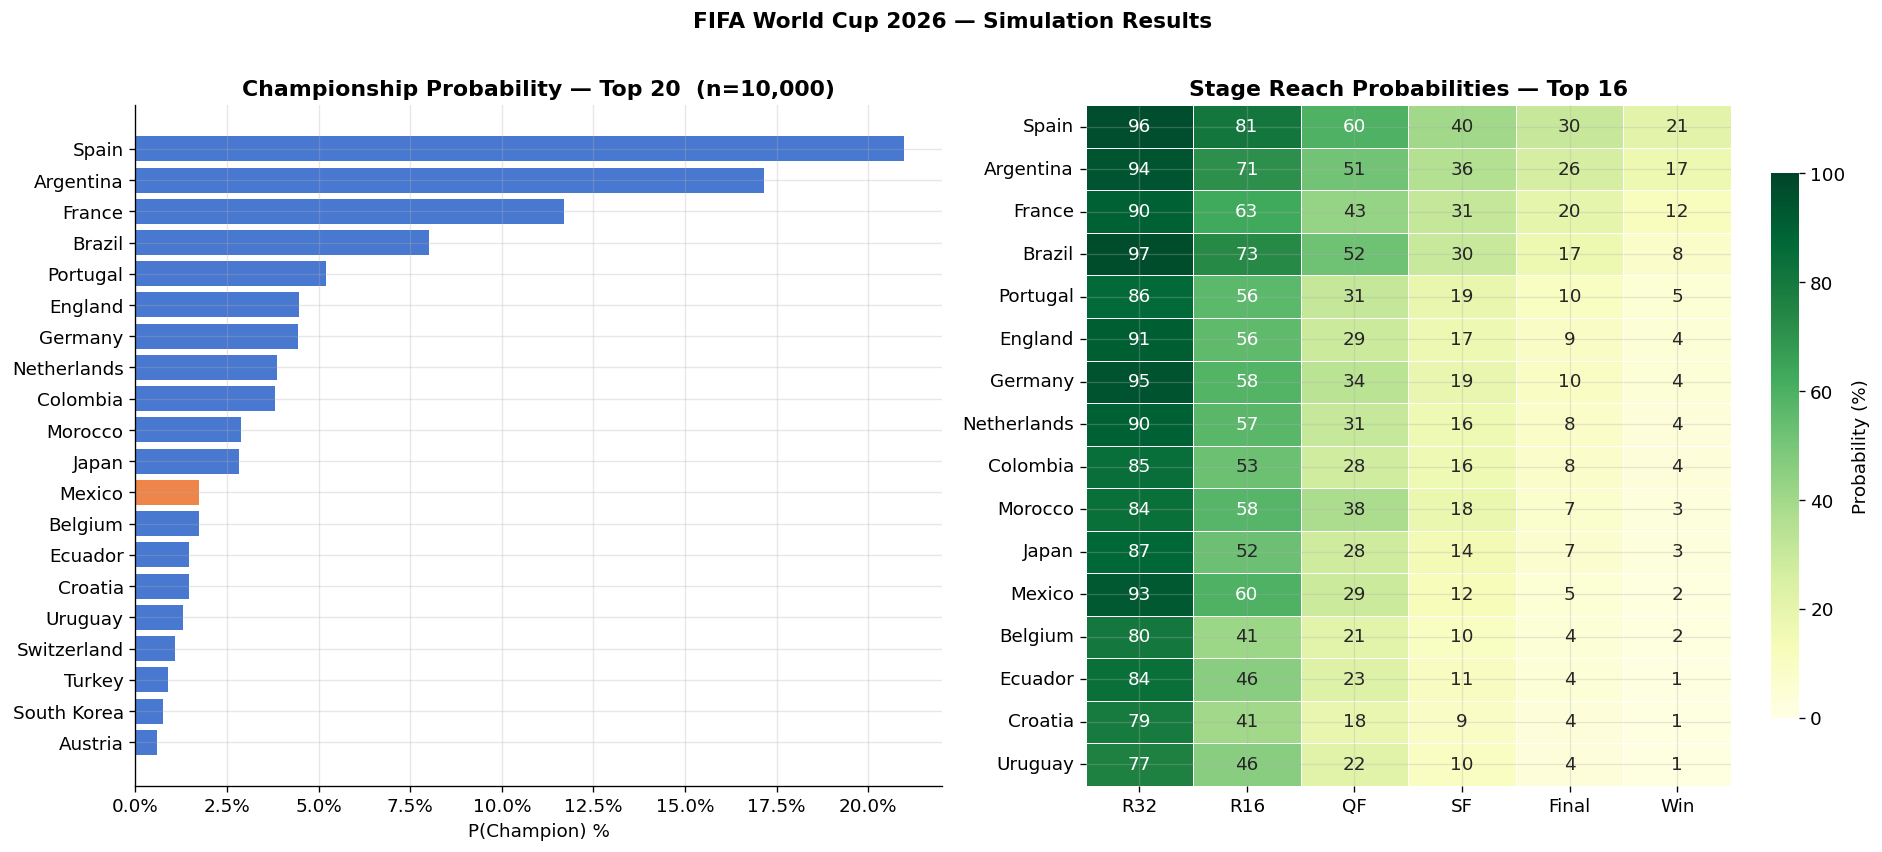

In [25]:
# Final visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top20 = df_sim.head(20)
host_mask = top20["team"].map(lambda t: team_meta.get(t,{}).get("host", False))
bar_colors = [PALETTE[1] if h else PALETTE[0] for h in host_mask]
axes[0].barh(top20["team"][::-1], top20["p_champion"][::-1]*100, color=bar_colors[::-1])
axes[0].set_title(f"Championship Probability — Top 20  (n={N_SIMS:,})", fontweight="bold")
axes[0].set_xlabel("P(Champion) %")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

top16 = df_sim.head(16)
stage_cols = ["p_r32","p_r16","p_qf","p_sf","p_final","p_champion"]
heat = top16[stage_cols].values * 100
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGn",
            xticklabels=["R32","R16","QF","SF","Final","Win"],
            yticklabels=top16["team"].tolist(),
            ax=axes[1], linewidths=0.3, vmin=0, vmax=100,
            cbar_kws={"shrink":0.8,"label":"Probability (%)"})
axes[1].set_title("Stage Reach Probabilities — Top 16", fontweight="bold")

plt.suptitle("FIFA World Cup 2026 — Simulation Results", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 8. Historical Retrodict — World Cups 2002 to 2022

For each World Cup from 2002 to 2022, the model is retrained using only
data available before that tournament started, then 5,000 simulations are
run to predict the champion. The actual result is compared against the model's
top-ranked team.

Groups and actual results come directly from the `jfjelstul/worldcup` database —
no hardcoding needed.

In [26]:
# Pull historical group structures and actual results from jfjelstul
# (already loaded in Section 2 as jf_groups and jf_tourn)

RETRO_YEARS = [2002, 2006, 2010, 2014, 2018, 2022]

# Name map: jfjelstul -> martj42 (only the mismatches that exist)
JF_TO_M42 = {
    "China":                  "China PR",
    "Serbia and Montenegro":  "Serbia and Montenegro",
    "Republic of Ireland":    "Republic of Ireland",
    "Ivory Coast":            "Ivory Coast",
}

def jf_name(name):
    return JF_TO_M42.get(name, name)

# Build groups dict per WC year from jf_groups
def get_historical_groups(year):
    tid = f"WC-{year}"
    sub = jf_groups[jf_groups["tournament_id"] == tid].copy()
    groups = {}
    for group, grp_df in sub.groupby("group_name"):
        teams = [jf_name(t) for t in grp_df["team_name"].tolist()]
        groups[group.replace("Group ", "")] = teams
    return groups

# Build actual results dict per WC year from jf_tourn
def get_actual_result(year):
    tid = f"WC-{year}"
    sub = jf_tourn[jf_tourn["tournament_id"] == tid].sort_values("position")
    result = {}
    for _, row in sub.iterrows():
        p = row["position"]
        name = jf_name(row["team_name"])
        if p == 1:  result["champion"]  = name
        if p == 2:  result["runner_up"] = name
        if p in [3,4]: result.setdefault("sf", []).append(name)
    return result

# Print what we have
print("Historical groups and results available:")
for yr in RETRO_YEARS:
    grps = get_historical_groups(yr)
    res  = get_actual_result(yr)
    teams_total = sum(len(v) for v in grps.values())
    print(f"  {yr}  groups={len(grps)}  teams={teams_total}  "
          f"champion={res.get('champion','?')}  runner-up={res.get('runner_up','?')}")


Historical groups and results available:
  2002  groups=8  teams=32  champion=Brazil  runner-up=Germany
  2006  groups=8  teams=32  champion=Italy  runner-up=France
  2010  groups=8  teams=32  champion=Spain  runner-up=Netherlands
  2014  groups=8  teams=32  champion=Germany  runner-up=Argentina
  2018  groups=8  teams=32  champion=France  runner-up=Croatia
  2022  groups=8  teams=32  champion=Argentina  runner-up=France


In [27]:
# Retrodict simulation engine
# Reuses sim_group and sim_match from Section 7.
# For each year: train model on all data before tournament, build prob_lookup
# for that year's group fixtures, run N_RETRO simulations.

N_RETRO = 5_000
RETRO_STAGES = ["group","r16","qf","sf","final","champion"]

def retro_elo_probs(ea, eb):
    diff = ea - eb
    pnl  = 1 / (1 + 10 ** (-diff/400))
    drw  = 0.27 * np.exp(-((diff/400)**2)/0.5)
    pa   = np.clip(pnl - drw/2, 0.02, 0.96)
    pb   = np.clip(1-pnl - drw/2, 0.02, 0.96)
    pd_  = np.clip(drw, 0.02, 0.60)
    arr  = np.array([pb, pd_, pa]); return arr/arr.sum()

def sim_retro_match(ta, tb, plookup, elo_snap, knockout=False):
    p = plookup.get((ta, tb))
    if p is None:
        ea = elo_snap.get(ta, 1500); eb = elo_snap.get(tb, 1500)
        p  = retro_elo_probs(ea, eb)
    if knockout:
        pb, _, pa = p; tot = pb + pa
        p = np.array([pb/tot, 0.0, pa/tot])
    p = np.clip(p, 0, 1); p /= p.sum()
    out = np.random.choice([0, 1, 2], p=p)
    if knockout: return (ta, tb) if out==2 else (tb, ta)
    return (3, 0) if out==2 else ((1, 1) if out==1 else (0, 3))

def sim_retro_group(teams, plookup, elo_snap):
    pts = {t:0 for t in teams}; gd = {t:0 for t in teams}
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            a, b = teams[i], teams[j]
            pa, pb = sim_retro_match(a, b, plookup, elo_snap, knockout=False)
            pts[a]+=pa; pts[b]+=pb
            if pa>pb: gd[a]+=1; gd[b]-=1
            elif pb>pa: gd[b]+=1; gd[a]-=1
    return sorted(teams, key=lambda t:(pts[t],gd[t],np.random.random()), reverse=True)

def sim_retro_tournament(groups_yr, plookup, elo_snap):
    all_teams = [t for tl in groups_yr.values() for t in tl]
    stage = {t:"group" for t in all_teams}

    r16_teams = []
    for g, teams in groups_yr.items():
        standing = sim_retro_group(teams, plookup, elo_snap)
        r16_teams.append(standing[0]); stage[standing[0]] = "r16"
        r16_teams.append(standing[1]); stage[standing[1]] = "r16"

    for next_s in ["qf","sf","final","champion"]:
        nxt = []
        for i in range(0, len(r16_teams)-1, 2):
            w, _ = sim_retro_match(r16_teams[i], r16_teams[i+1],
                                   plookup, elo_snap, knockout=True)
            nxt.append(w); stage[w] = next_s
        r16_teams = nxt
        if len(r16_teams) == 1:
            stage[r16_teams[0]] = "champion"; break

    return stage

print("Retrodict engine ready.")


Retrodict engine ready.


In [28]:
# Run retrodict for 2002-2022
np.random.seed(99)
all_retro_results = []

for year in RETRO_YEARS:
    print(f"\nWC {year}")

    groups_yr  = get_historical_groups(year)
    actual     = get_actual_result(year)
    tourney_start = pd.Timestamp(f"{year}-06-01")

    # All teams in this year's WC
    all_yr_teams = [t for tl in groups_yr.values() for t in tl]

    # Train on everything strictly before this tournament
    df_prior = df_train[pd.to_datetime(df_train["date"]) < tourney_start].copy()
    if len(df_prior) < 50:
        print(f"  Not enough training data, skipping.")
        continue

    X_pr = df_prior[FEATURE_COLS].values
    y_pr = df_prior["outcome"].values
    w_pr = df_prior["weight"].values

    xgb_yr = train_xgb(X_pr, y_pr, w_pr)
    poi_yr  = DoublePoisson()
    poi_yr.fit(df_prior[["home_team","away_team","home_goals","away_goals"]])

    # Elo snapshot just before tournament
    elo_snap_yr = {}
    for team in all_yr_teams:
        elo_snap_yr[team] = get_elo_before(elo_lookup, team, tourney_start)

    # Pre-compute match probabilities for all group pairs
    plookup_yr = {}
    for g, teams in groups_yr.items():
        for i in range(len(teams)):
            for j in range(i+1, len(teams)):
                ta, tb = teams[i], teams[j]
                feats = build_features(ta, tb, tourney_start, True,
                                       results, elo_lookup, team_meta)
                X_m = np.array([[feats[c] for c in FEATURE_COLS]])
                xp  = xgb_yr.predict_proba(X_m)[0]
                pp  = poi_yr.predict_proba(ta, tb, neutral=True)
                ens = blend(xp.reshape(1,-1), pp.reshape(1,-1), w=0.6)[0]
                plookup_yr[(ta, tb)] = ens
                plookup_yr[(tb, ta)] = ens[::-1].copy()

    # Run simulations
    stage_counts_yr = {t:{s:0 for s in RETRO_STAGES} for t in all_yr_teams}
    for _ in range(N_RETRO):
        result = sim_retro_tournament(groups_yr, plookup_yr, elo_snap_yr)
        for team, stage in result.items():
            idx = RETRO_STAGES.index(stage)
            for s in RETRO_STAGES[:idx+1]:
                stage_counts_yr[team][s] += 1

    # Build results table
    retro_rows = []
    for team, counts in stage_counts_yr.items():
        retro_rows.append({
            "year": year,
            "team": team,
            "p_champion": round(counts["champion"]/N_RETRO, 4),
            "p_final":    round(counts["final"]/N_RETRO, 4),
            "p_sf":       round(counts["sf"]/N_RETRO, 4),
        })
    df_yr = (pd.DataFrame(retro_rows)
             .sort_values("p_champion", ascending=False)
             .reset_index(drop=True))
    df_yr["rank"] = df_yr.index + 1

    champion = actual.get("champion", "?")
    runner   = actual.get("runner_up", "?")
    sf_teams = actual.get("sf", [])

    champ_row = df_yr[df_yr["team"] == champion]
    champ_rank = int(champ_row["rank"].values[0]) if len(champ_row) else "N/A"
    champ_prob = float(champ_row["p_champion"].values[0]) if len(champ_row) else 0.0

    print(f"  Actual champion : {champion}")
    print(f"  Model rank      : #{champ_rank}  (p_win = {champ_prob:.1%})")
    print(f"  Top 6 predicted:")
    for _, row in df_yr.head(6).iterrows():
        tag = ""
        if row["team"] == champion: tag = " <- CHAMPION"
        elif row["team"] == runner:   tag = " <- runner-up"
        elif row["team"] in sf_teams: tag = " <- semi-finalist"
        print(f"    {int(row['rank'])}. {row['team']:<22} {row['p_champion']:.1%}{tag}")

    all_retro_results.append(df_yr)

print("\nRetrodict complete.")



WC 2002
  Actual champion : Brazil
  Model rank      : #2  (p_win = 12.8%)
  Top 6 predicted:
    1. Spain                  13.0%
    2. Brazil                 12.8% <- CHAMPION
    3. France                 11.2%
    4. Argentina              10.4%
    5. Portugal               7.1%
    6. Italy                  7.0%

WC 2006
  Actual champion : Italy
  Model rank      : #8  (p_win = 5.9%)
  Top 6 predicted:
    1. France                 14.7% <- runner-up
    2. Spain                  12.5%
    3. Brazil                 10.3%
    4. Netherlands            9.1%
    5. England                8.9%
    6. Germany                7.1% <- semi-finalist

WC 2010
  Actual champion : Spain
  Model rank      : #1  (p_win = 23.6%)
  Top 6 predicted:
    1. Spain                  23.6% <- CHAMPION
    2. Brazil                 18.3%
    3. Netherlands            11.6% <- runner-up
    4. England                11.1%
    5. Argentina              7.7%
    6. Germany                6.6% <- semi-fi

In [29]:
# Retrodict summary table and visualisation
summary_rows = []
for year, df_yr in zip(RETRO_YEARS, all_retro_results):
    actual    = get_actual_result(year)
    champion  = actual.get("champion", "?")
    runner    = actual.get("runner_up", "?")
    sf_teams  = actual.get("sf", [])

    champ_row  = df_yr[df_yr["team"] == champion]
    runner_row = df_yr[df_yr["team"] == runner]
    champ_rank = int(champ_row["rank"].values[0]) if len(champ_row) else 99
    runner_rank= int(runner_row["rank"].values[0]) if len(runner_row) else 99

    sf_ranks = []
    for t in sf_teams:
        row = df_yr[df_yr["team"] == t]
        sf_ranks.append(int(row["rank"].values[0]) if len(row) else 99)

    summary_rows.append({
        "year":       year,
        "champion":   champion,
        "champ_rank": champ_rank,
        "champ_prob": float(champ_row["p_champion"].values[0]) if len(champ_row) else 0.0,
        "runner_up":  runner,
        "runner_rank":runner_rank,
        "champ_in_top3": champ_rank <= 3,
        "champ_in_top5": champ_rank <= 5,
        "both_finalists_top6": champ_rank <= 6 and runner_rank <= 6,
    })

df_summary = pd.DataFrame(summary_rows)

print("Retrodict accuracy summary (2002-2022)")
print("=" * 65)
print(f"{'Year':<6} {'Champion':<22} {'Rank':>5} {'P(win)':>7}  {'In Top3?':<10} {'In Top5?'}")
print("-" * 65)
for _, row in df_summary.iterrows():
    t3 = "Yes" if row["champ_in_top3"] else "No"
    t5 = "Yes" if row["champ_in_top5"] else "No"
    print(f"  {int(row['year']):<4} {row['champion']:<22} #{int(row['champ_rank']):<4} "
          f"{row['champ_prob']:>7.1%}  {t3:<10} {t5}")
print("-" * 65)
print(f"  Champion in top 3: {df_summary['champ_in_top3'].sum()}/{len(df_summary)} tournaments")
print(f"  Champion in top 5: {df_summary['champ_in_top5'].sum()}/{len(df_summary)} tournaments")
print(f"  Both finalists in top 6: {df_summary['both_finalists_top6'].sum()}/{len(df_summary)} tournaments")


Retrodict accuracy summary (2002-2022)
Year   Champion                Rank  P(win)  In Top3?   In Top5?
-----------------------------------------------------------------
  2002 Brazil                 #2      12.8%  Yes        Yes
  2006 Italy                  #8       5.9%  No         No
  2010 Spain                  #1      23.6%  Yes        Yes
  2014 Germany                #3      13.1%  Yes        Yes
  2018 France                 #4       8.9%  No         Yes
  2022 Argentina              #4      10.0%  No         Yes
-----------------------------------------------------------------
  Champion in top 3: 3/6 tournaments
  Champion in top 5: 5/6 tournaments
  Both finalists in top 6: 3/6 tournaments


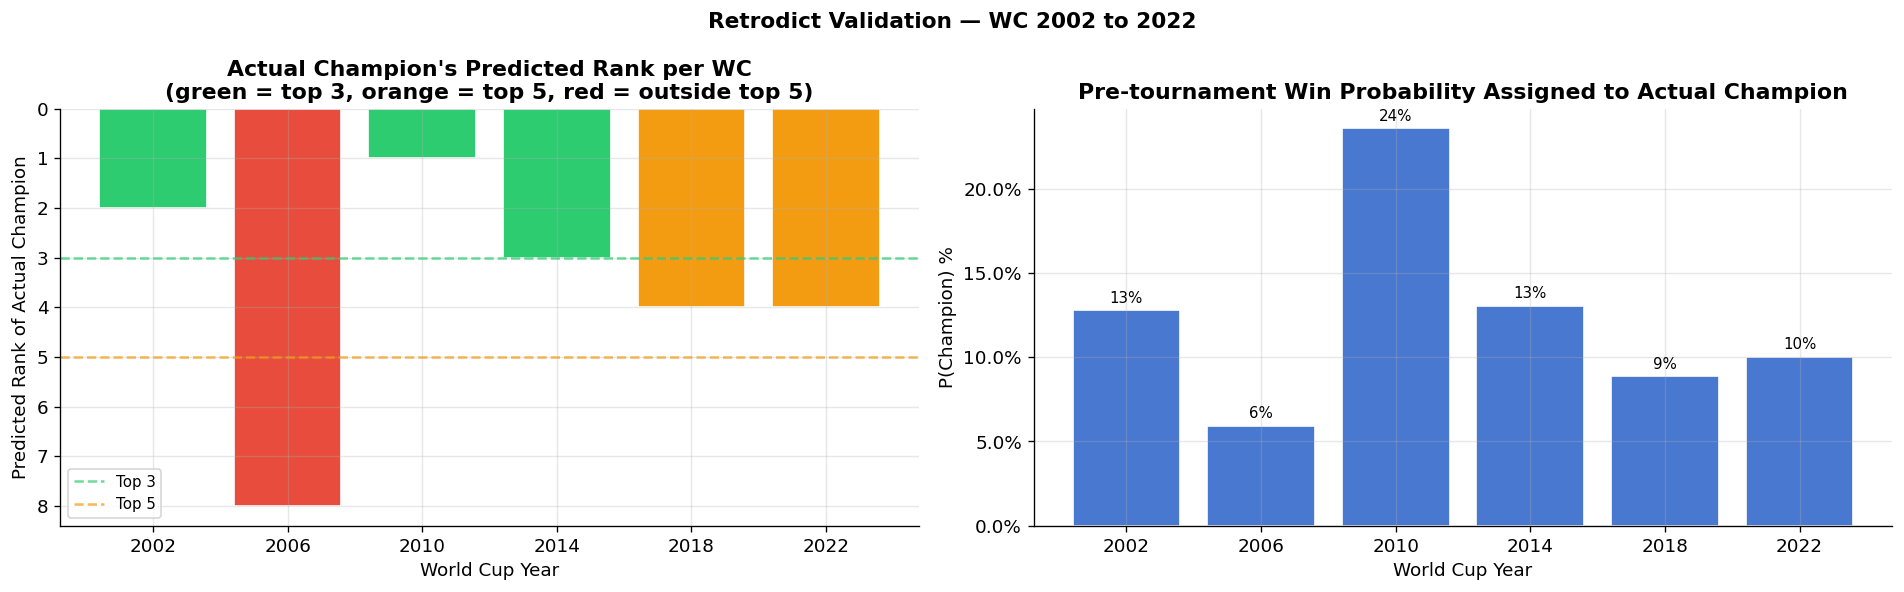

In [30]:
# Retrodict visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Champion rank per WC year
years_plot = df_summary["year"].tolist()
ranks      = df_summary["champ_rank"].tolist()
colors_bar = ["#2ecc71" if r <= 3 else ("#f39c12" if r <= 5 else "#e74c3c") for r in ranks]

axes[0].bar([str(y) for y in years_plot], ranks, color=colors_bar, edgecolor="white")
axes[0].axhline(3, color="#2ecc71", linestyle="--", linewidth=1.5, alpha=0.7, label="Top 3")
axes[0].axhline(5, color="#f39c12", linestyle="--", linewidth=1.5, alpha=0.7, label="Top 5")
axes[0].set_title("Actual Champion's Predicted Rank per WC\n(green = top 3, orange = top 5, red = outside top 5)",
                  fontweight="bold")
axes[0].set_xlabel("World Cup Year"); axes[0].set_ylabel("Predicted Rank of Actual Champion")
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# Champion win probability per WC year
probs = df_summary["champ_prob"].tolist()
axes[1].bar([str(y) for y in years_plot], [p*100 for p in probs], color=PALETTE[0], edgecolor="white")
for i, (y, p) in enumerate(zip(years_plot, probs)):
    axes[1].text(i, p*100 + 0.3, f"{p:.0%}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Pre-tournament Win Probability Assigned to Actual Champion",
                  fontweight="bold")
axes[1].set_xlabel("World Cup Year"); axes[1].set_ylabel("P(Champion) %")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("Retrodict Validation — WC 2002 to 2022", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
